Используя базу "Аудиожанры", примените подход к музыке как к тексту и напишите сверточный классификатор (на базе слоя Conv1D) для подготовленных данных. Для этого:

1. Измените подготовку данных так, чтобы набор признаков, извлекаемый из аудиофайла, был представлен в виде последовательностей векторов признаков. Последовательности должны быть фиксированного размера и выбираться скользящим окном c заданным шагом. Другими словами: берем аудио-файл длительность, например, 30 сек. Берем отрезок фиксированной длины (например, 5с) и получаем набор признаков для этого отрезка. Смещаемся на шаг (например, 1с) и берем следующий отрезок. Таким образом готовим обучающую вборку.
2. Длину последовательности, размер шага и достаточный набор признаков определите самостоятельно исходя из требований к точности классификатора;
3. Разработайте классификатор на одномерных сверточных слоях **Conv1D** с точностью классификации жанра на тестовых данных не ниже **60%**, а на обучающих файлах - **68%** и выше;
4. Используйте за основу материал с урока, но при желании разработайте свои инструменты.

Импортируем необходимые библиотеки:

In [ ]:
# Массивы
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Загрузка из google облака
import gdown

# Преобразование категориальных данных в one hot encoding
from tensorflow.keras.utils import to_categorical

# Работа с папками и файлами
import os

# Утилиты работы со временем
import time

# Работа со случайными числами
import random

# Математические функции
import math

# Сохранение и загрузка структур данных Python
import pickle

# Параметризация аудио
import librosa

# Оптимизаторы для обучения моделей
from tensorflow.keras.optimizers import Adam, RMSprop

# Конструирование и загрузка моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model, load_model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM
from tensorflow.keras.layers import MaxPooling1D, AveragePooling1D, SpatialDropout1D

# Разбиение на обучающую и проверочную выборку
from sklearn.model_selection import train_test_split

# Кодирование категориальных меток, нормирование числовых данных
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

Загрузим датасет в Colab:

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip', None, quiet=True)

'genres.zip'

In [ ]:
# Распаковка архива на локальный диск colab
!unzip -qo genres.zip

# Проверка выгруженных папок
!ls genres

# Проверка содержимого одной папки
!ls genres/blues

blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock
blues.00000.au	blues.00020.au	blues.00040.au	blues.00060.au	blues.00080.au
blues.00001.au	blues.00021.au	blues.00041.au	blues.00061.au	blues.00081.au
blues.00002.au	blues.00022.au	blues.00042.au	blues.00062.au	blues.00082.au
blues.00003.au	blues.00023.au	blues.00043.au	blues.00063.au	blues.00083.au
blues.00004.au	blues.00024.au	blues.00044.au	blues.00064.au	blues.00084.au
blues.00005.au	blues.00025.au	blues.00045.au	blues.00065.au	blues.00085.au
blues.00006.au	blues.00026.au	blues.00046.au	blues.00066.au	blues.00086.au
blues.00007.au	blues.00027.au	blues.00047.au	blues.00067.au	blues.00087.au
blues.00008.au	blues.00028.au	blues.00048.au	blues.00068.au	blues.00088.au
blues.00009.au	blues.00029.au	blues.00049.au	blues.00069.au	blues.00089.au
blues.00010.au	blues.00030.au	blues.00050.au	blues.00070.au	blues.00090.au
blues.00011.au	blues.00031.au	blues.00051.au	blues.00071.au	blues.00091.au
blues.00012.au	blues.00032.a

In [ ]:
# Ваше решение

# Папка с файлами датасета
FILE_DIR = './genres'
# Список классов
CLASS_LIST = os.listdir(FILE_DIR)
CLASS_LIST.sort()
CLASS_COUNT = len(CLASS_LIST)

# Файлы и их разбиение
CLASS_FILES = 100              # всего файлов в каждом классе
FILE_INDEX_TRAIN_SPLIT = 90    # первые 90 → обучение/валидация, последние 10 → тест
VALIDATION_SPLIT = 0.1

# Параметры аудио и окна
DURATION_SEC = 30      # анализируемая длительность файла
WINDOW_SEC   = 5       # длина одного отрезка (окна)
STEP_SEC     = 1       # шаг скользящего окна

# Параметры извлечения признаков librosa
N_FFT      = 2048
HOP_LENGTH = 512

print('Классы:', CLASS_LIST)
print('Количество классов:', CLASS_COUNT)

Классы: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Количество классов: 10


## 2. Функции извлечения признаков

Для каждого отрезка считаем тот же набор признаков, что и в Lite-версии, но **без усреднения по времени** — нам нужны последовательности векторов. Затем подрезаем все отрезки до одинаковой длины по времени.

In [ ]:
# Извлечение признаков для одного аудио-отрезка
def extract_features(y, sr, n_fft=N_FFT, hop_length=HOP_LENGTH):
    # Хромаграмма (12, T)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # MFCC (20, T)
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # RMSE (1, T)
    rmse   = librosa.feature.rms(y=y, hop_length=hop_length)
    # Спектральный центроид (1, T)
    cent   = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Ширина полосы частот (1, T)
    bw     = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Спектральный rolloff (1, T)
    roll   = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Пересечения нуля (1, T)
    zcr    = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)

    # Подрезаем все признаки до одинаковой длины по оси времени
    min_t = min(chroma.shape[1], mfcc.shape[1], rmse.shape[1],
                cent.shape[1], bw.shape[1], roll.shape[1], zcr.shape[1])

    feats = np.vstack([
        chroma[:, :min_t],
        mfcc[:, :min_t],
        rmse[:, :min_t],
        cent[:, :min_t],
        bw[:, :min_t],
        roll[:, :min_t],
        zcr[:, :min_t]
    ])
    # Возвращаем форму (время, признаки) — как «последовательность векторов»
    return feats.T.astype('float32')

## 3. Формирование последовательностей из аудиофайла

In [ ]:
# Из одного файла получаем список последовательностей (по скользящему окну)
def file_to_sequences(file_path, window_sec=WINDOW_SEC, step_sec=STEP_SEC,
                     duration_sec=DURATION_SEC):
    y, sr = librosa.load(file_path, mono=True, duration=duration_sec)

    window_len = int(window_sec * sr)
    step_len   = int(step_sec * sr)

    sequences = []
    start = 0
    while start + window_len <= len(y):
        segment = y[start:start + window_len]
        seq = extract_features(segment, sr)
        sequences.append(seq)
        start += step_len

    return sequences  # список массивов (T, F)

## 4. Сборка датасета по всем классам

In [ ]:
# Сбор данных в массивы
def build_dataset(file_index_start, file_index_end):
    x_data, y_data = [], []
    curr_time = time.time()

    for class_index in range(CLASS_COUNT):
        class_name = CLASS_LIST[class_index]
        for file_index in range(file_index_start, file_index_end):
            file_name = f'{FILE_DIR}/{class_name}/{class_name}.{str(file_index).zfill(5)}.au'
            seqs = file_to_sequences(file_name)
            for s in seqs:
                x_data.append(s)
                y_data.append(class_index)
        print(f'Жанр {class_name} готов -> {round(time.time() - curr_time)} c')
        curr_time = time.time()

    return np.array(x_data, dtype='float32'), np.array(y_data, dtype='int32')

# Обучающе-валидационный набор (файлы 0..89)
x_trainval, y_trainval = build_dataset(0, FILE_INDEX_TRAIN_SPLIT)
# Тестовый набор (файлы 90..99)
x_test, y_test = build_dataset(FILE_INDEX_TRAIN_SPLIT, CLASS_FILES)

print('x_trainval:', x_trainval.shape)  # (N, T, F)
print('x_test:    ', x_test.shape)

Жанр blues готов -> 199 c
Жанр classical готов -> 182 c
Жанр country готов -> 180 c
Жанр disco готов -> 181 c
Жанр hiphop готов -> 180 c
Жанр jazz готов -> 181 c
Жанр metal готов -> 183 c
Жанр pop готов -> 182 c
Жанр reggae готов -> 190 c
Жанр rock готов -> 180 c
Жанр blues готов -> 17 c
Жанр classical готов -> 19 c
Жанр country готов -> 17 c
Жанр disco готов -> 17 c
Жанр hiphop готов -> 17 c
Жанр jazz готов -> 19 c
Жанр metal готов -> 17 c
Жанр pop готов -> 17 c
Жанр reggae готов -> 18 c
Жанр rock готов -> 17 c
x_trainval: (23391, 216, 37)
x_test:     (2600, 216, 37)


## 5. Нормировка признаков и разбиение train/val

StandardScaler работает с 2D данными. Сглаживаем по оси времени → нормируем → разворачиваем обратно.

In [ ]:
# Размерности
n_train, T, F = x_trainval.shape
n_test = x_test.shape[0]

# Нормировка (fit только на train, чтобы избежать утечки)
x_scaler = StandardScaler()
x_trainval_2d = x_trainval.reshape(-1, F)
x_scaler.fit(x_trainval_2d)

x_trainval_scaled = x_scaler.transform(x_trainval_2d).reshape(n_train, T, F)
x_test_scaled     = x_scaler.transform(x_test.reshape(-1, F)).reshape(n_test, T, F)

# One-hot для меток
y_trainval_oh = to_categorical(y_trainval, CLASS_COUNT)
y_test_oh     = to_categorical(y_test, CLASS_COUNT)

# Разбиение train/val
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval_scaled, y_trainval_oh,
    stratify=y_trainval,
    test_size=VALIDATION_SPLIT,
    random_state=42
)

print('x_train:', x_train.shape, 'y_train:', y_train.shape)
print('x_val:  ', x_val.shape,   'y_val:  ', y_val.shape)
print('x_test: ', x_test_scaled.shape, 'y_test: ', y_test_oh.shape)

x_train: (21051, 216, 37) y_train: (21051, 10)
x_val:   (2340, 216, 37) y_val:   (2340, 10)
x_test:  (2600, 216, 37) y_test:  (2600, 10)


## 6. Архитектура свёрточного классификатора Conv1D

Аналог текстового CNN: несколько свёрточных блоков с пулингом, затем GlobalAveragePooling и полносвязная голова.

In [ ]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))

# Блок 1
model.add(Conv1D(128, kernel_size=5, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(SpatialDropout1D(0.2))

# Блок 2
model.add(Conv1D(128, kernel_size=5, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(SpatialDropout1D(0.3))

# Блок 3
model.add(Conv1D(64, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(AveragePooling1D(pool_size=2))
model.add(SpatialDropout1D(0.3))

# Голова классификатора
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(CLASS_COUNT, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 216, 128)       │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 216, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 108, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 108, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 108, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 54, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 54, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 54, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 54, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 27, 64)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 27, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       110,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,082 (949.54 KB)

 Trainable params: 242,442 (947.04 KB)

 Non-trainable params: 640 (2.50 KB)

## 7. Обучение модели

In [ ]:
history = model.fit(x_train, y_train,
                    batch_size=64,
                    epochs=50,
                    validation_data=(x_val, y_val),
                    verbose=1)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.4684 - loss: 1.6294 - val_accuracy: 0.7141 - val_loss: 0.8441
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6313 - loss: 1.0739 - val_accuracy: 0.7744 - val_loss: 0.6696
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6948 - loss: 0.8937 - val_accuracy: 0.8188 - val_loss: 0.5623
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7309 - loss: 0.7775 - val_accuracy: 0.8449 - val_loss: 0.4707
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7627 - loss: 0.6923 - val_accuracy: 0.8504 - val_loss: 0.4345
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7857 - loss: 0.6240 - val_accuracy: 0.8744 - val_loss: 0.3721
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8116 - loss: 0.5658 - val_accuracy: 0.8872 - val_loss: 0.3312
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8284 - loss: 0.5065 - val_accuracy: 

## 8. Графики обучения

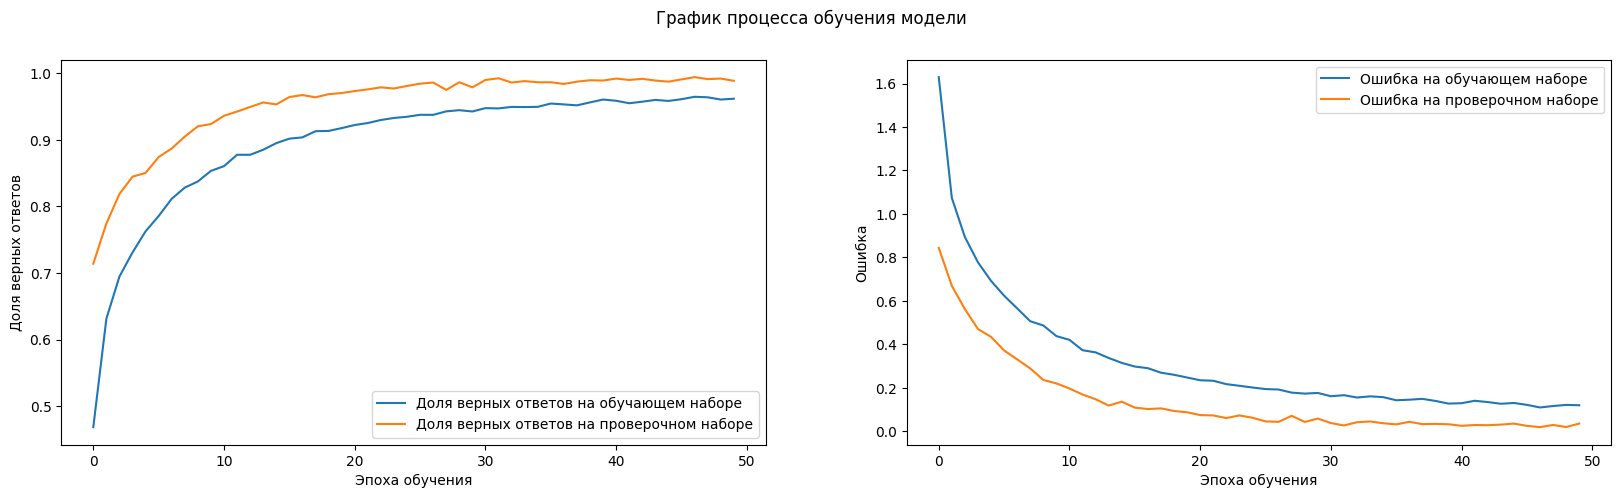

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('График процесса обучения модели')

ax1.plot(history.history['accuracy'], label='Доля верных ответов на обучающем наборе')
ax1.plot(history.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
ax1.set_xlabel('Эпоха обучения')
ax1.set_ylabel('Доля верных ответов')
ax1.legend()

ax2.plot(history.history['loss'], label='Ошибка на обучающем наборе')
ax2.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
ax2.set_xlabel('Эпоха обучения')
ax2.set_ylabel('Ошибка')
ax2.legend()

plt.show()

## 9. Оценка на тестовом наборе

Оцениваем двумя способами:
1. По отрезкам — просто `model.evaluate` на отрезках тестового набора
2. По файлам — для каждого файла усредняем предсказания всех его отрезков (голосование)

In [ ]:
# Оценка по отрезкам
test_loss, test_acc = model.evaluate(x_test_scaled, y_test_oh, verbose=0)
print(f'Точность по отрезкам: {test_acc * 100:.2f}%')

# Оценка по файлам (по 26 отрезков на файл при WINDOW_SEC=5, STEP_SEC=1, DURATION=30)
seqs_per_file = (DURATION_SEC - WINDOW_SEC) // STEP_SEC + 1
print(f'Отрезков на файл: {seqs_per_file}')

# Предсказание по всем тестовым отрезкам
y_pred_probs = model.predict(x_test_scaled, verbose=0)

# Группируем по файлам и усредняем
n_test_files = x_test_scaled.shape[0] // seqs_per_file
y_file_true, y_file_pred = [], []
for i in range(n_test_files):
    start = i * seqs_per_file
    end   = start + seqs_per_file
    avg_probs = y_pred_probs[start:end].mean(axis=0)
    y_file_pred.append(np.argmax(avg_probs))
    y_file_true.append(y_test[start])

y_file_true = np.array(y_file_true)
y_file_pred = np.array(y_file_pred)

file_acc = (y_file_true == y_file_pred).mean()
print(f'Точность по файлам (голосование): {file_acc * 100:.2f}%')

# Точность на обучающем наборе
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f'Точность на обучающей выборке: {train_acc * 100:.2f}%')

Точность по отрезкам: 72.27%
Отрезков на файл: 26
Точность по файлам (голосование): 76.00%
Точность на обучающей выборке: 99.65%


## 10. Матрица ошибок по тестовым файлам

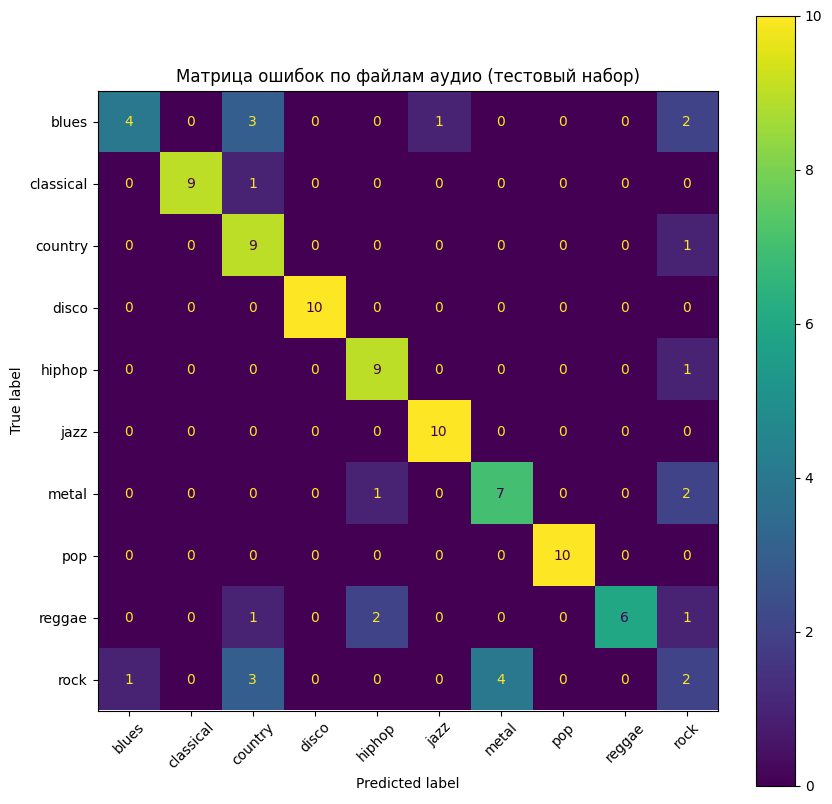

In [ ]:
cm = confusion_matrix(y_file_true, y_file_pred)
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title('Матрица ошибок по файлам аудио (тестовый набор)')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
disp.plot(ax=ax, xticks_rotation=45)
plt.show()